# 2025 Season Forecast — Full Pipeline (Retrained on 2016–2024)

Self-contained fit → simulate → evaluate notebook.

**Data splits**
- Training (regression + classification): 2016–2024 (`fg_hitters_train.csv` + `fg_hitters_test.csv`)
- Validation (evaluation target): 2025 (`fg_hitters_validation.csv`)

**Regression models fitted (6 total)**

| Label | Type | Features |
|-------|------|----------|
| `wRC_homo` | PyMC BLR | wRC+_t1 |
| `BBK_Brl_homo` | PyMC BLR | BB−K%_t1, Barrel%_t1 |
| `wRC_delta_homo` | PyMC BLR | wRC+_t1, Δ(wRC+) |
| `BMC` | Bayesian MARCEL | hierarchical, full predictive SD |
| `BMC_theta` | Bayesian MARCEL | same mean, parameter-uncertainty SD only |
| `MARCEL` | Deterministic MARCEL | 3-yr weighted avg + age adj. |

**Classification models fitted (3 + rookie fallback)**

| Tag | Features |
|-----|----------|
| `lr_m02` | wRC+, starter_t1, PA_t1 |
| `lr_m07` | wRC+, wRC+_t1, starter_t1, Def_t1 |
| `lr_m09` | wRC+, wRC+_t1, starter_t1, BsR_t1, Def_t1, same_team_t1×starter_t1 |
| rookie | wRC+, Age |

**Outputs**
- Individual regression evaluation: RMSE, MAE, 94% predictive coverage per model
- Classification evaluation: confusion matrices (3 models)
- Team wRC+ simulation: RMSE, MAE, 80% coverage vs. actual 2025 team wRC+

In [ ]:
import sys
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from itertools import product

# Locate the project root (directory that contains data/fangraphs/fg_hitters.csv)
data_path = Path.cwd()
while not (data_path / "data" / "fangraphs" / "fg_hitters.csv").exists() and data_path != data_path.parent:
    data_path = data_path.parent
DATA_DIR = data_path
print(f"DATA_DIR = {DATA_DIR}")

# Add project root to sys.path so `from src.models.marcel import ...` works
# regardless of which directory Jupyter was launched from
if str(DATA_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_DIR))

# ── Simulation parameters ─────────────────────────────────────────────────────
N            = 1000
TEAM_BUDGET  = 6100
STARTER_CAP  = 5400
PA_BY_ROLE   = {'bench': 70, 'platoon': 350, 'starter': 600}
OHTANI_IDFG  = 19755

REGRESSION_MODELS = {
    'BMC':            ('BMC_mean',            'BMC_pred_sd'),
    'BMC_theta':      ('BMC_theta_mean',      'BMC_theta_sd'),
    'wRC_homo':       ('wRC_homo_mean',        'wRC_homo_sd'),
    'BBK_Brl_homo':   ('BBK_Brl_homo_mean',    'BBK_Brl_homo_sd'),
    'wRC_delta_homo': ('wRC_delta_homo_mean',   'wRC_delta_homo_sd'),
}
CLASSIFICATION_MODELS = ['lr_m02', 'lr_m07', 'lr_m09']
ROLE_ORDER = ['bench', 'platoon', 'starter']
PA_ARRAY   = np.array([PA_BY_ROLE[r] for r in ROLE_ORDER], dtype=float)

print(f"N={N}  TEAM_BUDGET={TEAM_BUDGET}  STARTER_CAP={STARTER_CAP}")
print(f"{len(REGRESSION_MODELS)} regression models x {len(CLASSIFICATION_MODELS)} classification models")

DATA_DIR = /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project
N=500  TEAM_BUDGET=6100  STARTER_CAP=5400
5 regression models x 3 classification models


In [2]:
train = pd.read_csv(DATA_DIR / 'data' / 'fg_builds' / 'fg_hitters_train.csv')
test  = pd.read_csv(DATA_DIR / 'data' / 'fg_builds' / 'fg_hitters_test.csv')
val   = pd.read_csv(DATA_DIR / 'data' / 'fg_builds' / 'fg_hitters_validation.csv')

# Combined 2016-2024 training pool
train_all = pd.concat([train, test], ignore_index=True)

team_wrc = pd.read_csv(DATA_DIR / 'data' / 'fangraphs' / 'fg_team_wrc_2024_2025.csv')
actual_2025 = team_wrc[team_wrc['Season'] == 2025].set_index('Team')['wRC+'].rename('actual_wRC+')

print(f"train_all: {len(train_all)} rows  seasons {sorted(train_all['Season'].unique())}")
print(f"val:       {len(val)} rows  seasons {sorted(val['Season'].unique())}")
print(f"actual_2025: {len(actual_2025)} teams")

train_all: 5759 rows  seasons [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
val:       668 rows  seasons [2025]
actual_2025: 30 teams


In [3]:
BASE_COLS = ["Name", "G", "PA", "IDfg", "Age", "Team", "Season", "wRC+"]
PRIOR_SEASON_PRED = ["PA", "BB%", "K%", "Pull%", "Hard%",
                     "Barrel%", "GB%", "FB%", "maxEV", "wRC+", "primary_pos"]
DELTA_VARS = [v for v in PRIOR_SEASON_PRED if v not in ("PA", "primary_pos")]


def build_regression_features(df, prior_source):
    base = df[BASE_COLS].copy()

    prior_cols = ["IDfg", "Season"] + PRIOR_SEASON_PRED
    prior_df   = prior_source[prior_cols].drop_duplicates(subset=["IDfg", "Season"])

    t1 = prior_df.copy()
    t1["Season"] = t1["Season"] + 1
    t1 = t1.rename(columns={col: f"{col}_t1" for col in PRIOR_SEASON_PRED})

    t2 = prior_df.copy()
    t2["Season"] = t2["Season"] + 2
    t2 = t2.rename(columns={col: f"{col}_t2" for col in PRIOR_SEASON_PRED})

    result = (
        base
        .merge(t1, on=["IDfg", "Season"], how="left")
        .merge(t2[["IDfg", "Season"] + [f"{col}_t2" for col in PRIOR_SEASON_PRED]],
               on=["IDfg", "Season"], how="left")
    )
    for col in DELTA_VARS:
        result[f"{col}_delta"] = result[f"{col}_t1"] - result[f"{col}_t2"]

    t2_drop = [f"{col}_t2" for col in PRIOR_SEASON_PRED if col != "PA"]
    result = result.drop(columns=t2_drop)

    result["Age2"]           = result["Age"] ** 2
    result["x0"]             = 1.0
    result["BB-K%_t1"]       = result["BB%_t1"] - result["K%_t1"]
    result["Barrel%_t1_log"] = np.log(result["Barrel%_t1"] * 100 + 0.01)
    return result


# Train regression features: 2017-2024 (prior source = train_all)
train_reg = build_regression_features(train_all, train_all)
train_reg = train_reg[train_reg["Season"] >= 2017].reset_index(drop=True)

# Validation regression features: 2025 (prior source = train_all)
val_reg = build_regression_features(val, train_all)

print(f"train_reg: {train_reg.shape}  seasons {sorted(train_reg['Season'].unique())}")
print(f"val_reg:   {val_reg.shape}   seasons {sorted(val_reg['Season'].unique())}")

train_reg: (5126, 33)  seasons [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
val_reg:   (668, 33)   seasons [2025]


In [4]:
# pos/rookie flags for filtering
pos_rook = pd.concat([
    train_all[["IDfg", "Season", "primary_pos", "rookie"]],
    val[["IDfg",  "Season", "primary_pos", "rookie"]],
]).drop_duplicates(subset=["IDfg", "Season"])

train_pm = train_reg.merge(pos_rook, on=["IDfg", "Season"], how="left")
val_pm   = val_reg.merge( pos_rook, on=["IDfg", "Season"], how="left")


def _pm_filter(df):
    is_ohtani  = df["IDfg"] == OHTANI_IDFG
    is_pitcher = df["primary_pos"] == "P"
    is_rookie  = df["rookie"] == 1
    return df[(~is_pitcher | is_ohtani) & (~is_rookie | is_ohtani)].copy()


train_pm = _pm_filter(train_pm)
val_pm   = _pm_filter(val_pm)

_base       = train_pm[(train_pm["PA"] >= 100) & (train_pm["PA_t1"] >= 100)]
train_m1m3  = _base[_base["Season"] <= 2024].reset_index(drop=True)
train_m2    = (
    _base[(_base["Season"] >= 2018) & (_base["Season"] <= 2024)]
    .dropna(subset=["wRC+_delta"])
    .reset_index(drop=True)
)

print(f"train_m1m3: {len(train_m1m3):,} rows")
print(f"train_m2:   {len(train_m2):,} rows")
print(f"val_pm:     {len(val_pm):,} rows")


def fit_bayesian_reg(name, feature_cols, df_train, heteroskedastic=False,
                     n_draws=1000, n_tune=1000, seed=42):
    work   = df_train.dropna(subset=feature_cols + ["wRC+", "PA"]).reset_index(drop=True)
    X_tr   = work[feature_cols].to_numpy(dtype=float)
    y_tr   = work["wRC+"].to_numpy(dtype=float)
    PA_tr  = work["PA"].to_numpy(dtype=float)
    n_feat = X_tr.shape[1]
    print(f"\n{'─'*60}\n  {name}  n={len(work):,}  hetero={heteroskedastic}\n{'─'*60}")
    with pm.Model() as model:
        X_data  = pm.MutableData("X_data",  X_tr)
        y_data  = pm.MutableData("y_data",  y_tr)
        pa_data = pm.MutableData("pa_data", PA_tr)
        intercept = pm.Normal("intercept", mu=100, sigma=20)
        beta      = pm.Normal("beta",      mu=0,   sigma=5, shape=n_feat)
        sigma_obs = pm.HalfNormal("sigma_obs", sigma=500)
        mu     = intercept + pm.math.dot(X_data, beta)
        obs_sd = sigma_obs / pm.math.sqrt(pa_data) if heteroskedastic else sigma_obs
        pm.Normal("y", mu=mu, sigma=obs_sd, observed=y_data)
        trace = pm.sample(draws=n_draws, tune=n_tune, target_accept=0.9,
                          random_seed=seed, nuts_sampler="numpyro", progressbar=True)
    meta = {"name": name, "feature_cols": feature_cols,
            "heteroskedastic": heteroskedastic, "n_train": len(work)}
    return model, trace, meta


PM_SPECS = [
    ("wRC_homo",       ["wRC+_t1"],               train_m1m3, False),
    ("wRC_delta_homo", ["wRC+_t1", "wRC+_delta"],  train_m2,   False),
    ("BBK_Brl_homo",   ["BB-K%_t1", "Barrel%_t1"],train_m1m3, False),
]

pm_results = {}
for name, features, df_tr, hetero in PM_SPECS:
    mdl, trc, meta = fit_bayesian_reg(name, features, df_tr, heteroskedastic=hetero)
    pm_results[name] = (mdl, trc, meta)

print("\nFitted models:", list(pm_results.keys()))

train_m1m3: 2,637 rows
train_m2:   2,063 rows
val_pm:     563 rows

────────────────────────────────────────────────────────────
  wRC_homo  n=2,637  hetero=False
────────────────────────────────────────────────────────────


/Users/johannhatzius/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:  40%|████      | 800/2000 [00:00<00:00, 7449.70it/s]


Running chain 1: 100%|██████████| 2000/2000 [00:01<00:00, 1901.22it/s]



────────────────────────────────────────────────────────────
  wRC_delta_homo  n=2,063  hetero=False
────────────────────────────────────────────────────────────


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]



Running chain 0:  40%|████      | 800/2000 [00:00<00:00, 7374.02it/s]


Running chain 0:  85%|████████▌ | 1700/2000 [00:00<00:00, 7989.61it/s]

Running chain 3: 100%|██████████| 2000/2000 [00:00<00:00, 2075.08it/s]



────────────────────────────────────────────────────────────
  BBK_Brl_homo  n=2,637  hetero=False
────────────────────────────────────────────────────────────


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]




Running chain 0:   5%|▌         | 100/2000 [00:00<00:05, 332.67it/s]


Running chain 0: 100%|██████████| 2000/2000 [00:01<00:00, 1842.50it/s]

Running chain 1: 100%|██████████| 2000/2000 [00:01<00:00, 1745.16it/s]



Fitted models: ['wRC_homo', 'wRC_delta_homo', 'BBK_Brl_homo']


In [5]:
from src.models.marcel import (
    load_and_filter, build_prediction_table, build_marcel_model, fit_marcel
)

# Load and filter (100 PA minimum), 2016-2024
df_bmc = train_all.copy()
df_bmc = df_bmc[df_bmc["PA"] >= 100]
cols_bmc = ["IDfg", "Season", "Name", "Age", "PA", "wRC+", "primary_pos"]
df_bmc = df_bmc[cols_bmc].drop_duplicates(subset=["IDfg", "Season"]).reset_index(drop=True)
df_bmc["player_season"] = df_bmc["IDfg"].astype(str) + "_" + df_bmc["Season"].astype(str)

# Build prediction table for in-sample fit (target seasons 2018-2024)
idx_map = {(row.IDfg, row.Season): i for i, row in df_bmc.iterrows()}
rows_pred = []
for target_season in range(2018, 2025):
    targets = df_bmc[df_bmc["Season"] == target_season]
    for _, tgt in targets.iterrows():
        pid   = tgt["IDfg"]
        idx_t1 = idx_map.get((pid, target_season - 1), -1)
        idx_t2 = idx_map.get((pid, target_season - 2), -1)
        n_prior = (idx_t1 != -1) + (idx_t2 != -1)
        if n_prior == 0:
            continue
        rows_pred.append({
            "IDfg": pid, "Name": tgt["Name"], "Season": target_season,
            "wRC+": tgt["wRC+"], "PA": tgt["PA"],
            "theta_idx_t1": idx_t1, "theta_idx_t2": idx_t2, "n_prior": n_prior,
        })

pred_df_bmc = pd.DataFrame(rows_pred).reset_index(drop=True)
pred_df_bmc["pred_key"] = pred_df_bmc["IDfg"].astype(str) + "_" + pred_df_bmc["Season"].astype(str)

print(f"BMC training data: {len(df_bmc):,} player-seasons  (2016-2024, ≥100 PA)")
print(f"BMC prediction rows: {len(pred_df_bmc):,}  (target seasons 2018-2024)")
print(f"n_prior distribution: {pred_df_bmc['n_prior'].value_counts().sort_index().to_dict()}")

# Fit full MARCEL model (Blocks 1+2+3, asymmetric-quadratic aging)
bmc_model = build_marcel_model(df_bmc, pred_df_bmc, n_seasons=2,
                               aging_form="asymmetric_quadratic")
bmc_trace = fit_marcel(bmc_model, target_accept=0.95, tune=2000, draws=1000,
                       chains=4, random_seed=42)

# Quick diagnostics
rhat_vals = [
    float(az.rhat(bmc_trace)["mu_theta"].values),
    float(az.rhat(bmc_trace)["sigma_theta"].values),
    float(az.rhat(bmc_trace)["sigma_obs"].values),
    float(az.rhat(bmc_trace)["theta_raw"].max().values),
]
print(f"\nMax R-hat: {max(rhat_vals):.4f}  (target ≤ 1.01)")
print(f"Divergences: {int(bmc_trace.sample_stats['diverging'].values.sum())}")
print(az.summary(bmc_trace, var_names=["mu_theta", "sigma_theta", "sigma_obs", "w",
                                        "a_0", "beta_young", "beta_old"]).round(3))

BMC training data: 3,930 player-seasons  (2016-2024, ≥100 PA)
BMC prediction rows: 2,464  (target seasons 2018-2024)
n_prior distribution: {1: 663, 2: 1801}


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_theta, sigma_theta, sigma_obs, theta_raw, w, a_0, beta_young, beta_old]
/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 19 seconds.
Sampling: [wrc_plus, wrc_pred]



Max R-hat: 1.0072  (target ≤ 1.01)
Divergences: 0
                mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_theta      99.548  0.425   98.730  100.334      0.010    0.007    1991.0   
sigma_theta   18.834  0.410   18.038   19.565      0.012    0.009    1149.0   
sigma_obs    382.175  4.755  373.704  391.217      0.122    0.087    1500.0   
w              0.553  0.052    0.457    0.648      0.002    0.001     801.0   
a_0           25.447  1.356   23.076   28.090      0.026    0.018    2799.0   
beta_young     0.076  0.092    0.000    0.247      0.002    0.001    2509.0   
beta_old       0.063  0.022    0.026    0.103      0.000    0.000    2654.0   

             ess_tail  r_hat  
mu_theta       2382.0    1.0  
sigma_theta    2105.0    1.0  
sigma_obs      2420.0    1.0  
w              1061.0    1.0  
a_0            3039.0    1.0  
beta_young     2247.0    1.0  
beta_old       2884.0    1.0  


In [6]:
TARGET = 2025

# Build index map from trace coordinates
ps_coords = bmc_trace.posterior.coords["player_season"].values
n_ps = len(ps_coords)

coord_df = pd.DataFrame({
    "IDfg":   [int(ps.rsplit("_", 1)[0]) for ps in ps_coords],
    "Season": [int(ps.rsplit("_", 1)[1]) for ps in ps_coords],
    "ps_idx": np.arange(n_ps),
}).merge(df_bmc[["IDfg", "Season", "Name", "Age", "PA"]],
         on=["IDfg", "Season"], how="left")

# Players with a 2024 season in the trace (these get t-1 index)
players_t1 = (
    coord_df[coord_df["Season"] == TARGET - 1]
    [["IDfg", "Name", "Age", "ps_idx", "PA"]]
    .copy()
    .rename(columns={"ps_idx": "idx_t1", "PA": "PA_t1"})
)
players_t1["Age_proj"] = players_t1["Age"].astype(int) + 1

# Look up t-2 (2023) indices
idx_t2_map = coord_df[coord_df["Season"] == TARGET - 2].set_index("IDfg")["ps_idx"]
pa_t2_map  = coord_df[coord_df["Season"] == TARGET - 2].set_index("IDfg")["PA"]
players_t1["idx_t2"] = players_t1["IDfg"].map(idx_t2_map).fillna(-1).astype(int)
players_t1["PA_t2"]  = players_t1["IDfg"].map(pa_t2_map)
players_t1["n_prior"] = ((players_t1["idx_t1"] != -1).astype(int)
                         + (players_t1["idx_t2"] != -1).astype(int))

proj_bmc = players_t1[players_t1["n_prior"] > 0].reset_index(drop=True)
proj_bmc["PA_prior"] = proj_bmc["PA_t1"].fillna(proj_bmc["PA_t2"])

print(f"Projecting {len(proj_bmc)} players for 2025")

# Extract posterior samples
theta_samp     = bmc_trace.posterior["theta"].values.reshape(-1, n_ps)
w_samp         = bmc_trace.posterior["w"].values.flatten()
a_0_samp       = bmc_trace.posterior["a_0"].values.flatten()
by_samp        = bmc_trace.posterior["beta_young"].values.flatten()
bo_samp        = bmc_trace.posterior["beta_old"].values.flatten()
sigma_obs_samp = bmc_trace.posterior["sigma_obs"].values.flatten()
n_samp = w_samp.shape[0]

idx_t1  = proj_bmc["idx_t1"].values.astype(int)
idx_t2  = proj_bmc["idx_t2"].values.astype(int)
ages    = proj_bmc["Age_proj"].values.astype(float)

safe_t1 = np.where(idx_t1 == -1, 0, idx_t1)
safe_t2 = np.where(idx_t2 == -1, 0, idx_t2)
mask1   = (idx_t1 != -1).astype(float)
mask2   = (idx_t2 != -1).astype(float)

theta_t1 = theta_samp[:, safe_t1]
theta_t2 = theta_samp[:, safe_t2]

w    = w_samp[:, None]
rw1  = w * mask1[None, :]
rw2  = (1.0 - w) * mask2[None, :]
theta_proj = (rw1 / (rw1 + rw2)) * theta_t1 + (rw2 / (rw1 + rw2)) * theta_t2

age_diff   = ages[None, :] - a_0_samp[:, None]
age_effect = np.where(age_diff >= 0,
                      -bo_samp[:, None] * age_diff**2,
                      -by_samp[:, None] * age_diff**2)

theta_proj_aged = theta_proj + age_effect   # (n_samp, n_players)

# Full predictive distribution (BMC): add observation noise
rng_bmc = np.random.default_rng(42)
pa_prior_arr = proj_bmc["PA_prior"].values.astype(float)
sigma_eff    = sigma_obs_samp[:, None] / np.sqrt(pa_prior_arr[None, :])
y_pred_bmc   = theta_proj_aged + rng_bmc.standard_normal(theta_proj_aged.shape) * sigma_eff

bmc_idx = proj_bmc["IDfg"].values
bmc_mean_s    = pd.Series(theta_proj_aged.mean(axis=0).round(1), index=bmc_idx)
bmc_pred_sd_s = pd.Series(y_pred_bmc.std(axis=0).round(1),       index=bmc_idx)
bmc_theta_sd_s= pd.Series(theta_proj_aged.std(axis=0).round(1),  index=bmc_idx)

# HDI bounds for individual regression evaluation
alpha = (1 - 0.94) / 2
bmc_lo_s = pd.Series(np.percentile(y_pred_bmc, alpha*100, axis=0).round(1), index=bmc_idx)
bmc_hi_s = pd.Series(np.percentile(y_pred_bmc, (1-alpha)*100, axis=0).round(1), index=bmc_idx)
bmc_theta_lo_s = pd.Series(np.percentile(theta_proj_aged, alpha*100, axis=0).round(1), index=bmc_idx)
bmc_theta_hi_s = pd.Series(np.percentile(theta_proj_aged, (1-alpha)*100, axis=0).round(1), index=bmc_idx)

print(f"BMC projections complete.  Top 5:")
top5 = proj_bmc.set_index("IDfg")[["Name","Age_proj"]].copy()
top5["BMC_mean"] = bmc_mean_s
top5.nlargest(5, "BMC_mean")[["Name","Age_proj","BMC_mean"]].pipe(print)

Projecting 455 players for 2025
BMC projections complete.  Top 5:
                 Name  Age_proj  BMC_mean
IDfg                                     
15640     Aaron Judge        33     165.7
19755   Shohei Ohtani        30     153.0
20123       Juan Soto        26     149.0
19556  Yordan Alvarez        28     141.8
25764  Bobby Witt Jr.        25     135.8


In [7]:
# Deterministic MARCEL using the 3 most recent available seasons (2022-2024)
# weight = (season_offset) * PA / 1000  where offset: 2022→3, 2023→4 (was 2→3), 2024→5
# (same formula as regressions.ipynb, but window shifted forward by 1 year)
marcel_base = train_all[train_all["Season"] >= 2022][
    ["IDfg", "Name", "Season", "Age", "primary_pos", "wRC+", "PA"]
].copy()
marcel_base["weight"]      = (marcel_base["Season"] - 2022 + 3) * marcel_base["PA"] / 1000
marcel_base["weighted_wrc"] = marcel_base["weight"] * marcel_base["wRC+"]

def _marcel_row(g):
    age_next = g["Age"].max() + 1
    raw = (g["weighted_wrc"].sum() + 120) / (g["weight"].sum() + 1.2)
    aging = (1 - 0.006 * (age_next - 29)) if age_next >= 29 else (1 + 0.003 * (29 - age_next))
    return raw * aging

marcel_det_preds = (
    marcel_base
    .groupby("IDfg", group_keys=False)
    .apply(_marcel_row)
    .reset_index()
)
marcel_det_preds.columns = ["IDfg", "MARCEL_mean"]

weight_sums = marcel_base.groupby("IDfg")["weight"].sum().rename("weight_sum")
marcel_det_preds = marcel_det_preds.merge(weight_sums, on="IDfg", how="left")

print(f"Deterministic MARCEL projections: {len(marcel_det_preds)} players")
print(marcel_det_preds.nlargest(5, "MARCEL_mean")[["IDfg","MARCEL_mean"]].to_string(index=False))

Deterministic MARCEL projections: 931 players
 IDfg  MARCEL_mean
15640   185.424637
19556   161.994103
19755   160.443142
20123   157.018983
13611   140.838906


/var/folders/3f/5z6bhnqn1fv15360tr2wfskr0000gn/T/ipykernel_58303/2046285005.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  marcel_base


In [8]:
def predict_pm(trace, meta, test_df, hdi_prob=0.94, seed=0):
    feature_cols    = meta["feature_cols"]
    heteroskedastic = meta["heteroskedastic"]
    work = test_df.dropna(subset=feature_cols + ["PA"]).copy()
    if len(work) == 0:
        empty = pd.Series(dtype=float)
        return empty, empty, empty
    X_te  = work[feature_cols].to_numpy(dtype=float)
    PA_te = work["PA"].to_numpy(dtype=float)
    intercept_d = trace.posterior["intercept"].values.flatten()
    beta_d      = trace.posterior["beta"].values.reshape(-1, len(feature_cols))
    sigma_d     = trace.posterior["sigma_obs"].values.flatten()
    mu_samps = intercept_d[:, None] + beta_d @ X_te.T
    if heteroskedastic:
        sigma_eff = sigma_d[:, None] / np.sqrt(PA_te[None, :])
    else:
        sigma_eff = np.tile(sigma_d[:, None], (1, len(work)))
    rng    = np.random.default_rng(seed)
    y_pred = mu_samps + rng.standard_normal(mu_samps.shape) * sigma_eff
    alpha  = (1 - hdi_prob) / 2
    idx    = work["IDfg"].values
    return (
        pd.Series(mu_samps.mean(axis=0).round(1), index=idx),
        pd.Series(np.percentile(y_pred, alpha*100, axis=0).round(1), index=idx),
        pd.Series(np.percentile(y_pred, (1-alpha)*100, axis=0).round(1), index=idx),
    )


pm_preds = {}   # name → (mean, lo, hi)  indexed by IDfg
for name, (mdl, trc, meta) in pm_results.items():
    pt, lo, hi = predict_pm(trc, meta, val_pm)
    pm_preds[name] = (pt, lo, hi)
    print(f"{name}: {pt.notna().sum()} predictions")

# ── Assemble full regression output table ────────────────────────────────────
reg_out = val[["IDfg", "Name", "Age", "primary_pos", "PA", "wRC+"]].copy()
reg_out = reg_out.rename(columns={"wRC+": "actual_wRC+"})

# PyMC models – mean and HDI bounds now; SD filled by the posterior-predictive loop below
for name in ["wRC_homo", "wRC_delta_homo", "BBK_Brl_homo"]:
    pt, lo, hi = pm_preds[name]
    reg_out[f"{name}_mean"] = reg_out["IDfg"].map(pt)
    reg_out[f"{name}_lo94"] = reg_out["IDfg"].map(lo)
    reg_out[f"{name}_hi94"] = reg_out["IDfg"].map(hi)

# BMC variants
reg_out["BMC_mean"]      = reg_out["IDfg"].map(bmc_mean_s)
reg_out["BMC_pred_sd"]   = reg_out["IDfg"].map(bmc_pred_sd_s)
reg_out["BMC_lo94"]      = reg_out["IDfg"].map(bmc_lo_s)
reg_out["BMC_hi94"]      = reg_out["IDfg"].map(bmc_hi_s)
reg_out["BMC_theta_mean"]   = reg_out["IDfg"].map(bmc_mean_s)
reg_out["BMC_theta_sd"]     = reg_out["IDfg"].map(bmc_theta_sd_s)
reg_out["BMC_theta_lo94"]   = reg_out["IDfg"].map(bmc_theta_lo_s)
reg_out["BMC_theta_hi94"]   = reg_out["IDfg"].map(bmc_theta_hi_s)

# Deterministic MARCEL (no interval)
reg_out["MARCEL_mean"] = reg_out["IDfg"].map(marcel_det_preds.set_index("IDfg")["MARCEL_mean"])

# Simulation-ready SD columns (needed downstream)
for pm_name in ["wRC_homo", "wRC_delta_homo", "BBK_Brl_homo"]:
    # use the posterior-predictive SD: std of y_pred across MCMC samples
    trc = pm_results[pm_name][1]
    meta = pm_results[pm_name][2]
    work = val_pm.dropna(subset=meta["feature_cols"] + ["PA"]).copy()
    X_te  = work[meta["feature_cols"]].to_numpy(dtype=float)
    PA_te = work["PA"].to_numpy(dtype=float)
    b_d   = trc.posterior["beta"].values.reshape(-1, len(meta["feature_cols"]))
    i_d   = trc.posterior["intercept"].values.flatten()
    s_d   = trc.posterior["sigma_obs"].values.flatten()
    mu_s  = i_d[:, None] + b_d @ X_te.T
    sigma_eff = np.tile(s_d[:, None], (1, len(work)))
    rng_ = np.random.default_rng(0)
    y_s  = mu_s + rng_.standard_normal(mu_s.shape) * sigma_eff
    sd_s = pd.Series(y_s.std(axis=0).round(1), index=work["IDfg"].values)
    reg_out[f"{pm_name}_sd"] = reg_out["IDfg"].map(sd_s)

print(f"reg_out: {reg_out.shape}")
print(reg_out[["Name","Age","PA","actual_wRC+","BMC_mean","wRC_homo_mean","MARCEL_mean"]].head(8).to_string(index=False))

wRC_homo: 535 predictions
wRC_delta_homo: 429 predictions
BBK_Brl_homo: 535 predictions
reg_out: (668, 27)
           Name  Age  PA  actual_wRC+  BMC_mean  wRC_homo_mean  MARCEL_mean
    Aaron Judge   33 679        204.0     165.7          149.6   185.424637
    Cal Raleigh   28 705        161.0     109.9          105.1   115.071826
 Bobby Witt Jr.   25 687        130.0     135.8          127.4   131.852198
  Shohei Ohtani   30 727        172.0     153.0          132.2   160.443142
Geraldo Perdomo   25 720        138.0     100.8           98.1    91.786260
    Trea Turner   32 639        125.0     108.1          107.3   113.942971
 Corbin Carroll   24 642        139.0     109.6          100.3   117.566461
   Jose Ramirez   32 673        133.0     120.4          115.2   127.654584


In [9]:
# Evaluate on validation players with ≥100 PA
eval_mask = reg_out["PA"] >= 100
ev = reg_out[eval_mask].copy()
actual = ev["actual_wRC+"].values

def rmse(p, a): return float(np.sqrt(np.mean((p - a) ** 2)))
def mae(p, a):  return float(np.mean(np.abs(p - a)))
def coverage(lo, hi, a):
    lo_a = np.asarray(lo, dtype=float)
    hi_a = np.asarray(hi, dtype=float)
    mask = np.isfinite(lo_a) & np.isfinite(hi_a)
    if mask.sum() == 0:
        return float('nan')
    return float(np.mean((a[mask] >= lo_a[mask]) & (a[mask] <= hi_a[mask])))

models_eval = {
    "wRC_homo":       (ev["wRC_homo_mean"],      ev["wRC_homo_lo94"],    ev["wRC_homo_hi94"]),
    "BBK_Brl_homo":   (ev["BBK_Brl_homo_mean"],  ev["BBK_Brl_homo_lo94"],ev["BBK_Brl_homo_hi94"]),
    "wRC_delta_homo": (ev["wRC_delta_homo_mean"], ev["wRC_delta_homo_lo94"],ev["wRC_delta_homo_hi94"]),
    "BMC":            (ev["BMC_mean"],            ev["BMC_lo94"],          ev["BMC_hi94"]),
    "BMC_theta":      (ev["BMC_theta_mean"],      ev["BMC_theta_lo94"],    ev["BMC_theta_hi94"]),
    "MARCEL":         (ev["MARCEL_mean"],         None,                    None),
}

reg_eval_rows = []
for name, (mean_, lo_, hi_) in models_eval.items():
    m_arr = mean_.values if hasattr(mean_, "values") else np.asarray(mean_, dtype=float)
    valid = np.isfinite(m_arr)
    reg_eval_rows.append({
        "model":        name,
        "n_players":    int(valid.sum()),
        "rmse":         round(rmse(m_arr[valid], actual[valid]), 3),
        "mae":          round(mae(m_arr[valid], actual[valid]), 3),
        "coverage_94":  round(coverage(lo_, hi_, actual), 3) if lo_ is not None else float('nan'),
    })

reg_eval_df = pd.DataFrame(reg_eval_rows)
print("Individual player regression evaluation (2025 validation, ≥100 PA)")
print(reg_eval_df.to_string(index=False))

# Save
out_path = DATA_DIR / "data" / "evaluation"
out_path.mkdir(parents=True, exist_ok=True)
reg_eval_df.to_csv(out_path / "reg_model_comparison_2025.csv", index=False)
print(f"\nSaved → {out_path / 'reg_model_comparison_2025.csv'}")

Individual player regression evaluation (2025 validation, ≥100 PA)
         model  n_players   rmse    mae  coverage_94
      wRC_homo        406 26.488 20.440        0.924
  BBK_Brl_homo        406 28.070 22.258        0.936
wRC_delta_homo        346 25.683 19.847        0.925
           BMC        362 24.604 19.226        0.914
     BMC_theta        362 24.604 19.226        0.588
        MARCEL        409 26.258 20.147          NaN

Saved → /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/data/evaluation/reg_model_comparison_2025.csv


In [10]:
CURRENT_COLS = ['IDfg','Name','Season','Team','Age','PA','wRC+',
                'primary_pos','rookie','same_team','role']
T1_FEAT_COLS = ['PA','GS_pct','G','GS','wRC+','primary_pos',
                'rookie','same_team','BsR','Def','Pace','role']


def build_model_df(train_df, test_df):
    all_df = pd.concat([train_df, test_df], ignore_index=True)
    t1 = (
        all_df[['IDfg','Season'] + T1_FEAT_COLS]
        .copy()
        .assign(Season=lambda d: d['Season'] + 1)
        .rename(columns={c: f'{c}_t1' for c in T1_FEAT_COLS})
    )
    mdf = all_df[CURRENT_COLS].merge(t1, on=['IDfg','Season'], how='left')
    mdf['rookie_t1'] = mdf['rookie_t1'].fillna(0)
    mdf['role_code'] = mdf['role'].map({r: i for i, r in enumerate(ROLE_ORDER)})
    return mdf[mdf['Season'] > 2016]


def add_pos_dummies(df, pos_col, prefix, ref_pos='LF'):
    dummies = pd.get_dummies(df[pos_col], prefix=prefix, dtype=float)
    ref_col = f'{prefix}_{ref_pos}'
    if ref_col in dummies.columns:
        dummies = dummies.drop(columns=ref_col)
    new_cols = [c for c in dummies.columns if c not in df.columns]
    if new_cols:
        df = pd.concat([df, dummies[new_cols]], axis=1)
    return df, list(dummies.columns)


# Full model_df: 2016-2025 (train_all provides t-1 for val)
model_df = build_model_df(train_all, val)
model_df, _ = add_pos_dummies(model_df, 'primary_pos',    'pos',    ref_pos='LF')
model_df, _ = add_pos_dummies(model_df, 'primary_pos_t1', 'pos_t1', ref_pos='LF')

# starter_t1 and interaction
model_df['starter_t1'] = (
    (model_df['role_t1'] == 'starter')
    .where(model_df['role_t1'].notna())
    .astype('Float64')
)
model_df['same_team_t1_x_starter_t1'] = model_df['same_team_t1'] * model_df['starter_t1']


def prep_for_lr(df):
    mask = (df['rookie'] != 1) & ((df['primary_pos'] != 'P') | (df['IDfg'] == OHTANI_IDFG))
    return df[mask].copy()


train_mdf = model_df[model_df['Season'] <= 2024]
val_mdf   = model_df[model_df['Season'] == 2025]

lr_train = prep_for_lr(train_mdf)
lr_val   = prep_for_lr(val_mdf)

print(f"model_df total: {len(model_df):,}")
print(f"lr_train: {len(lr_train):,}  seasons {sorted(lr_train['Season'].unique())}")
print(f"lr_val:   {len(lr_val):,}  season 2025")

model_df total: 5,794
lr_train: 4,221  seasons [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
lr_val:   563  season 2025


In [28]:
def fit_ordered_logit(train_df, feature_cols, include_rookies=True,
                      n_draws=1000, n_tune=1000, target_accept=0.9, random_seed=42):
    K  = len(ROLE_ORDER)
    df = train_df[train_df['role_code'].notna()].copy()
    if not include_rookies:
        df = df[df['rookie'] != 1]
    df = df.dropna(subset=feature_cols + ['role_code']).reset_index(drop=True)
    print(f"  Fitting on {len(df):,} obs  (include_rookies={include_rookies})")

    X = df[feature_cols].copy()
    scaler = {}
    for col in feature_cols:
        if df[col].nunique() > 2:
            mu, sigma = df[col].mean(), df[col].std()
            if sigma > 0:
                X[col] = (X[col] - mu) / sigma
                scaler[col] = {'mean': float(mu), 'std': float(sigma)}

    X_np = X.to_numpy(dtype=float)
    y_np = df['role_code'].to_numpy(dtype=int)

    with pm.Model() as model:
        X_data = pm.Data('X', X_np, mutable=True)
        y_data = pm.Data('y', y_np, mutable=True)
        beta = pm.Normal('beta', mu=0, sigma=2.5, shape=X_np.shape[1])
        cutpoints = pm.Normal('cutpoints', mu=0, sigma=5, shape=K-1,
                              transform=pm.distributions.transforms.ordered,
                              initval=np.linspace(-2.0, 2.0, K-1))
        eta = pm.math.dot(X_data, beta)
        pm.OrderedLogistic('role', eta=eta, cutpoints=cutpoints, observed=y_data)

    with model:
        trace = pm.sample(draws=n_draws, tune=n_tune, target_accept=target_accept,
                          random_seed=random_seed, nuts_sampler='numpyro', progressbar=True)
        pm.sample_posterior_predictive(trace, extend_inferencedata=True)

    meta = {'feature_cols': feature_cols, 'scaler': scaler,
            'role_order': ROLE_ORDER, 'n_obs': len(df)}
    return model, trace, meta


def compute_role_probs(trace, meta, df):
    feature_cols = meta['feature_cols']
    X = df[feature_cols].astype(float).copy()
    for col, params in meta['scaler'].items():
        X[col] = (X[col] - params['mean']) / params['std']
    X_np = X.to_numpy()
    beta = trace.posterior['beta'].values.reshape(-1, len(feature_cols))
    cp   = trace.posterior['cutpoints'].values.reshape(-1, 2)
    eta  = X_np @ beta.T
    cum  = sp.special.expit(cp[np.newaxis] - eta[:, :, np.newaxis])
    pad0 = np.zeros((len(X_np), beta.shape[0], 1))
    pad1 = np.ones( (len(X_np), beta.shape[0], 1))
    prbs = np.diff(np.concatenate([pad0, cum, pad1], axis=2), axis=2)
    return prbs.mean(axis=1)


def predict_roles(trace, meta, df):
    feature_cols = meta['feature_cols']
    work = df.dropna(subset=feature_cols).copy().reset_index(drop=True)
    if len(work) == 0:
        return pd.DataFrame()
    probs = compute_role_probs(trace, meta, work)
    result = work[['IDfg','Name','Season','Age','PA','wRC+','role','role_code']].copy()
    for j, r in enumerate(ROLE_ORDER):
        result[f'p_{r}'] = probs[:, j]
    result['pred_role'] = pd.Categorical(
        [ROLE_ORDER[i] for i in probs.argmax(axis=1)], categories=ROLE_ORDER, ordered=True
    )
    result['correct'] = result['pred_role'] == result['role']
    return result


LR_SPECS = [
    ('1', ['wRC+', 'starter_t1', 'PA_t1']),
    ('m07', ['wRC+', 'wRC+_t1', 'starter_t1', 'Def_t1']),
    ('2', ['wRC+', 'wRC+_t1', 'starter_t1', 'BsR_t1', 'Def_t1',
             'same_team_t1_x_starter_t1']),
]

lr_results = {}
for tag, feats in LR_SPECS:
    print(f'\n{"="*50}\nlr_{tag}: {feats}\n{"="*50}')
    _, trc, meta = fit_ordered_logit(lr_train, feats, include_rookies=False)
    val_p   = predict_roles(trc, meta, lr_val)
    train_p = predict_roles(trc, meta, lr_train)
    lr_results[tag] = (trc, meta, train_p, val_p)
    known_te = val_p[val_p['role_code'].notna()]
    print(f"  Val accuracy: {known_te['correct'].mean():.1%}  ({len(known_te)} players)")

# Rookie model (wRC+ + Age, fitted on all rookies in train_all)
rook_df = train_all[train_all['rookie'] == 1].copy()
rook_df = rook_df.dropna(subset=['wRC+','Age','role']).query("role in @ROLE_ORDER")
rook_df['role_code'] = rook_df['role'].map({r: i for i, r in enumerate(ROLE_ORDER)})
rook_df = rook_df.reset_index(drop=True)

_, rook_trace, rook_meta = fit_ordered_logit(
    rook_df, ['wRC+','Age'], include_rookies=True,
    n_draws=1000, n_tune=1000, random_seed=42
)
print(f"\nRookie model fitted on {rook_meta['n_obs']:,} obs")


lr_1: ['wRC+', 'starter_t1', 'PA_t1']
  Fitting on 4,029 obs  (include_rookies=False)


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]


Running chain 0:  10%|█         | 200/2000 [00:00<00:00, 1927.54it/s]




Running chain 0:  40%|████      | 800/2000 [00:01<00:00, 2537.31it/s]




Running chain 0:  55%|█████▌    | 1100/2000 [00:01<00:00, 2435.98it/s]



Running chain 0:  70%|███████   | 1400/2000 [00:01<00:00, 2236.76it/s]


Running chain 0:  85%|████████▌ | 1700/2000 [00:01<00:00, 2135.77it/s]

Running chain 1: 100%|██████████| 2000/2000 [00:01<00:00, 1296.73it/s]

Running chain 0: 100%|██████████| 2000/2000 [00:01<00:00, 1189.23it/s]
Sampling: [role]


  Val accuracy: 68.2%  (535 players)

lr_m07: ['wRC+', 'wRC+_t1', 'starter_t1', 'Def_t1']
  Fitting on 4,026 obs  (include_rookies=False)


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:  10%|█         | 200/2000 [00:00<00:01, 1557.21it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:00<00:00, 2128.42it/s]


Running chain 0:  40%|████      | 800/2000 [00:01<00:00, 2354.20it/s]


Running chain 0:  55%|█████▌    | 1100/2000 [00:01<00:00, 2464.95it/s]


Running chain 0:  70%|███████   | 1400/2000 [00:01<00:00, 2493.76it/s]


Running chain 1: 100%|██████████| 2000/2000 [00:01<00:00, 1287.51it/s]



Running chain 0: 100%|██████████| 2000/2000 [00:01<00:00, 1275.31it/s]
Sampling: [role]


  Val accuracy: 64.5%  (535 players)

lr_2: ['wRC+', 'wRC+_t1', 'starter_t1', 'BsR_t1', 'Def_t1', 'same_team_t1_x_starter_t1']
  Fitting on 4,001 obs  (include_rookies=False)


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]




Running chain 0:  10%|█         | 200/2000 [00:00<00:01, 1428.64it/s]


Running chain 0:  20%|██        | 400/2000 [00:01<00:00, 1677.52it/s]


Running chain 0:  30%|███       | 600/2000 [00:01<00:00, 1725.94it/s]



Running chain 0:  45%|████▌     | 900/2000 [00:01<00:00, 1883.61it/s]

Running chain 0:  55%|█████▌    | 1100/2000 [00:01<00:00, 1809.51it/s]


Running chain 0:  65%|██████▌   | 1300/2000 [00:01<00:00, 1713.19it/s]


Running chain 0:  75%|███████▌  | 1500/2000 [00:01<00:00, 1654.13it/s]


Running chain 0:  85%|████████▌ | 1700/2000 [00:01<00:00, 1607.77it/s]


Running chain 2: 100%|██████████| 2000/2000 [00:01<00:00, 1014.81it/s]
Sampling: [role]


  Val accuracy: 64.6%  (534 players)
  Fitting on 900 obs  (include_rookies=True)


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]



Running chain 0:  75%|███████▌  | 1500/2000 [00:00<00:00, 14309.30it/s]

Running chain 3: 100%|██████████| 2000/2000 [00:00<00:00, 2418.35it/s] 
Sampling: [role]



Rookie model fitted on 900 obs


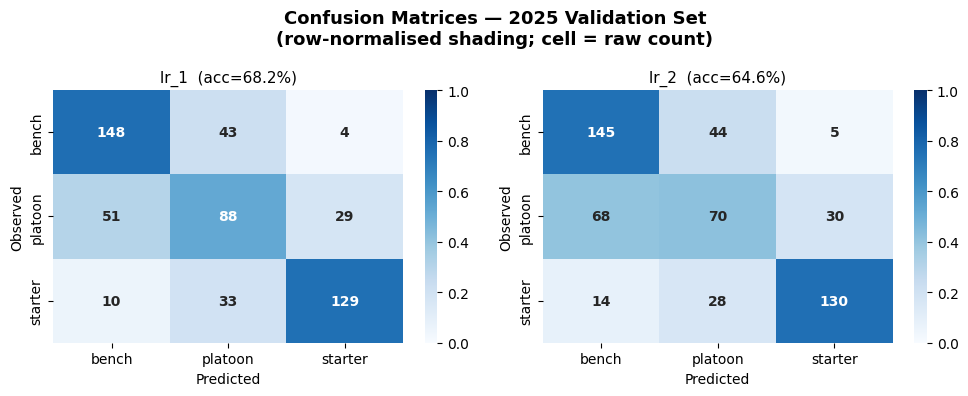

Saved → data/evaluation/cls_confusion_2025.png

Per-role accuracy (val set):
role   bench  platoon  starter
model                         
lr_1   0.759    0.524    0.750
lr_2   0.747    0.417    0.756


In [29]:
PLOT_MODELS = ['1', '2']   # m07 excluded from output

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Confusion Matrices — 2025 Validation Set\n(row-normalised shading; cell = raw count)',
             fontsize=13, fontweight='bold')

for ax, tag in zip(axes, PLOT_MODELS):
    _, _, _, val_p = lr_results[tag]
    known = val_p[val_p['role_code'].notna()]
    cm_raw  = pd.crosstab(known['role'], known['pred_role'],
                          rownames=['Observed'], colnames=['Predicted']
                          ).reindex(index=ROLE_ORDER, columns=ROLE_ORDER, fill_value=0)
    cm_norm = cm_raw.div(cm_raw.sum(axis=1), axis=0)
    acc = known['correct'].mean()

    sns.heatmap(cm_norm, annot=cm_raw.values, fmt='d', cmap='Blues',
                vmin=0, vmax=1, ax=ax,
                annot_kws={'size': 10, 'weight': 'bold'})
    ax.set_title(f'lr_{tag}  (acc={acc:.1%})', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Observed')

plt.tight_layout()
plt.savefig(DATA_DIR / 'data' / 'evaluation' / 'cls_confusion_2025.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/evaluation/cls_confusion_2025.png")

# Per-model accuracy table (m02 and m09 only)
acc_rows = []
for tag in PLOT_MODELS:
    _, _, train_p, val_p = lr_results[tag]
    ktr = train_p[train_p['role_code'].notna()]
    kte = val_p[val_p['role_code'].notna()]
    for role in ROLE_ORDER:
        tr_r = ktr[ktr['role'] == role]
        te_r = kte[kte['role'] == role]
        acc_rows.append({
            'model': f'lr_{tag}', 'split': 'train', 'role': role,
            'n': len(tr_r),
            'accuracy': round(tr_r['correct'].mean(), 3) if len(tr_r) else float('nan'),
        })
        acc_rows.append({
            'model': f'lr_{tag}', 'split': 'val', 'role': role,
            'n': len(te_r),
            'accuracy': round(te_r['correct'].mean(), 3) if len(te_r) else float('nan'),
        })

acc_df = pd.DataFrame(acc_rows)
print("\nPer-role accuracy (val set):")
print(acc_df[acc_df['split']=='val'].pivot(index='model', columns='role', values='accuracy').round(3).to_string())


In [13]:
# Simulation player table for 2025 (mirrors run_simulation.py but for val/2025)
players = val[['IDfg','Name','Team','Age','wRC+','primary_pos',
               'rookie','role','same_team']].copy()

# ── Attach regression projections ────────────────────────────────────────────
sim_reg_cols = ['Name', 'team_start']
for mean_col, sd_col in REGRESSION_MODELS.values():
    sim_reg_cols += [mean_col, sd_col]

# Use mean_col / sd_col directly from REGRESSION_MODELS — these are the exact
# column names in reg_out.  Constructing f"{name_key}_sd" would give "BMC_sd"
# instead of "BMC_pred_sd", silently leaving BMC SD as NaN in the sim table.
reg_sim = reg_out[['IDfg','Name']].copy()
for name_key, (mean_col, sd_col) in REGRESSION_MODELS.items():
    if mean_col in reg_out.columns:
        reg_sim[mean_col] = reg_out[mean_col].values
    if sd_col in reg_out.columns:
        reg_sim[sd_col]   = reg_out[sd_col].values

# team_start (from val)
reg_sim = reg_sim.merge(val[['IDfg','team_start']].drop_duplicates('IDfg'),
                        on='IDfg', how='left')

players = players.merge(
    reg_sim.drop(columns=['Name']),
    on='IDfg', how='left'
)
players['team_start'] = players['team_start'].fillna(players['Team'])

# Fallback for missing projections
for mean_col, sd_col in REGRESSION_MODELS.values():
    missing = players[mean_col].isna()
    players.loc[missing & (players['Age'] <= 25), mean_col] = 86.0
    players.loc[missing & (players['Age'] <= 25), sd_col]   = 12.0
    players.loc[missing & (players['Age'] >  25), mean_col] = 76.0
    players.loc[missing & (players['Age'] >  25), sd_col]   =  5.0

# ── Join t-1 features (2024 = test set) ──────────────────────────────────────
t1 = (
    test[['IDfg','PA','GS_pct','wRC+','BsR','Def','role','same_team']]
    .rename(columns={'PA':'PA_t1','GS_pct':'GS_pct_t1','wRC+':'wRC+_t1',
                     'BsR':'BsR_t1','Def':'Def_t1',
                     'role':'role_t1','same_team':'same_team_t1'})
)
players = players.merge(t1, on='IDfg', how='left')

players['starter_t1'] = (
    (players['role_t1'] == 'starter')
    .where(players['role_t1'].notna())
    .astype('Float64')
)
players['same_team_t1_x_starter_t1'] = players['same_team_t1'] * players['starter_t1']

MODEL_T1_FEATURES = {
    'lr_m02': ['starter_t1', 'PA_t1'],
    'lr_m07': ['wRC+_t1', 'starter_t1', 'Def_t1'],
    'lr_m09': ['wRC+_t1', 'starter_t1', 'BsR_t1', 'Def_t1', 'same_team_t1_x_starter_t1'],
}
for model, feats in MODEL_T1_FEATURES.items():
    players[f'has_t1_{model}'] = players[feats].notna().all(axis=1)

players = players.reset_index(drop=True)
print(f"Simulation player table: {len(players)} rows x {players.shape[1]} cols")
print(f"  team_start NaN: {players['team_start'].isna().sum()}")
for m in CLASSIFICATION_MODELS:
    n_main = players[f'has_t1_{m}'].sum()
    print(f"  {m}: {n_main} main  |  {len(players)-n_main} rookie fallback")

# Store classification traces in the format expected by simulation functions
class_traces = {f'lr_{t}': trc for t, (trc, *_) in lr_results.items()}
class_metas  = {f'lr_{t}': meta for t, (_, meta, *_) in lr_results.items()}

Simulation player table: 668 rows x 32 cols
  team_start NaN: 0
  lr_m02: 535 main  |  133 rookie fallback
  lr_m07: 535 main  |  133 rookie fallback
  lr_m09: 534 main  |  134 rookie fallback


In [14]:
def _normalize_pa(roles, raw_pa, players, teams):
    n       = len(players)
    norm_pa = np.zeros(n)
    for team in teams:
        tm           = (players['team_start'] == team).to_numpy()
        is_starter   = (roles == 2) & tm
        is_non_start = (roles != 2) & tm
        raw_s_total  = raw_pa[is_starter].sum()
        if raw_s_total > STARTER_CAP:
            norm_pa[is_starter] = raw_pa[is_starter] * STARTER_CAP / raw_s_total
            starter_final = STARTER_CAP
        else:
            norm_pa[is_starter] = raw_pa[is_starter]
            starter_final = float(raw_s_total)
        non_start_budget = TEAM_BUDGET - starter_final
        raw_ns_total     = raw_pa[is_non_start].sum()
        if raw_ns_total > 0:
            norm_pa[is_non_start] = raw_pa[is_non_start] * non_start_budget / raw_ns_total
        elif is_non_start.sum() > 0:
            norm_pa[is_non_start] = non_start_budget / is_non_start.sum()
    return norm_pa


def run_simulation(players, reg_model, class_model, N=500, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    mean_col, sd_col = REGRESSION_MODELS[reg_model]
    reg_mean = players[mean_col].to_numpy(dtype=float)
    reg_sd   = players[sd_col].to_numpy(dtype=float)
    has_t1   = players[f'has_t1_{class_model}'].to_numpy(dtype=bool)
    trace_c  = class_traces[class_model]
    meta_c   = class_metas[class_model]
    n        = len(players)
    teams    = players['team_start'].dropna().unique()
    wrc_sims = np.zeros((N, n))
    pa_sims  = np.zeros((N, n))
    for i in range(N):
        wrc_i = rng.normal(reg_mean, reg_sd)
        wrc_sims[i] = wrc_i
        probs = np.zeros((n, 3))
        if has_t1.sum() > 0:
            df_main = players[has_t1].copy(); df_main['wRC+'] = wrc_i[has_t1]
            probs[has_t1] = compute_role_probs(trace_c, meta_c, df_main)
        if (~has_t1).sum() > 0:
            df_fall = players[~has_t1].copy(); df_fall['wRC+'] = wrc_i[~has_t1]
            probs[~has_t1] = compute_role_probs(rook_trace, rook_meta, df_fall)
        cumpr  = probs.cumsum(axis=1)
        u      = rng.random(n)[:, np.newaxis]
        roles  = (u > cumpr).sum(axis=1)
        pa_sims[i] = _normalize_pa(roles, PA_ARRAY[roles], players, teams)
    return wrc_sims, pa_sims


def run_deterministic(players, reg_model, class_model):
    mean_col, _ = REGRESSION_MODELS[reg_model]
    reg_mean    = players[mean_col].to_numpy(dtype=float)
    has_t1      = players[f'has_t1_{class_model}'].to_numpy(dtype=bool)
    trace_c     = class_traces[class_model]
    meta_c      = class_metas[class_model]
    n           = len(players)
    teams       = players['team_start'].dropna().unique()
    df_work = players.copy(); df_work['wRC+'] = reg_mean
    probs = np.zeros((n, 3))
    if has_t1.sum() > 0:
        probs[has_t1] = compute_role_probs(trace_c, meta_c, df_work[has_t1])
    if (~has_t1).sum() > 0:
        probs[~has_t1] = compute_role_probs(rook_trace, rook_meta, df_work[~has_t1])
    roles  = probs.argmax(axis=1)
    pa_det = _normalize_pa(roles, PA_ARRAY[roles], players, teams)
    return reg_mean, pa_det


print("Simulation functions defined: _normalize_pa, run_simulation, run_deterministic")

Simulation functions defined: _normalize_pa, run_simulation, run_deterministic


In [15]:
results_p1 = {}   # (reg, cls) → {'wrc_sims': (N,n), 'pa_sims': (N,n)}
results_p2 = {}   # (reg, cls) → {'wrc_det': (n,),   'pa_det':  (n,)}

rng      = np.random.default_rng(0)
n_combos = len(REGRESSION_MODELS) * len(CLASSIFICATION_MODELS)
done     = 0

for reg_name, class_name in product(REGRESSION_MODELS, CLASSIFICATION_MODELS):
    done += 1
    print(f"[{done:>2}/{n_combos}] {reg_name} x {class_name}", flush=True)
    wrc_sims, pa_sims = run_simulation(players, reg_name, class_name, N=N, rng=rng)
    results_p1[(reg_name, class_name)] = {'wrc_sims': wrc_sims, 'pa_sims': pa_sims}
    wrc_det, pa_det = run_deterministic(players, reg_name, class_name)
    results_p2[(reg_name, class_name)] = {'wrc_det': wrc_det, 'pa_det': pa_det}

print(f"\nDone — {done} p1 + {done} p2 combinations.")

# ── Build team output ─────────────────────────────────────────────────────────
teams = sorted(players['team_start'].dropna().unique())
team_rows = {t: {'team': t} for t in teams}

for (reg_name, class_name), sims in results_p1.items():
    col_prefix = f"{reg_name}_{class_name}_p1"
    wrc_sims, pa_sims = sims['wrc_sims'], sims['pa_sims']
    for team in teams:
        tm       = (players['team_start'] == team).to_numpy()
        team_avg = (wrc_sims[:, tm] * pa_sims[:, tm]).sum(axis=1) / TEAM_BUDGET
        team_rows[team][f'{col_prefix}_mean']   = round(float(team_avg.mean()), 2)
        team_rows[team][f'{col_prefix}_median'] = round(float(np.median(team_avg)), 2)
        team_rows[team][f'{col_prefix}_p10']    = round(float(np.percentile(team_avg, 10.0)), 2)
        team_rows[team][f'{col_prefix}_p90']    = round(float(np.percentile(team_avg, 90.0)), 2)

for (reg_name, class_name), det in results_p2.items():
    col_prefix = f"{reg_name}_{class_name}_p2"
    wrc_det, pa_det = det['wrc_det'], det['pa_det']
    for team in teams:
        tm = (players['team_start'] == team).to_numpy()
        team_rows[team][f'{col_prefix}_wRC+'] = round(float((wrc_det[tm] * pa_det[tm]).sum() / TEAM_BUDGET), 2)

team_df = pd.DataFrame(list(team_rows.values())).set_index('team').sort_index()
out_team = DATA_DIR / 'data' / 'model_outputs' / 'model_team_sim_2025.csv'
out_team.parent.mkdir(parents=True, exist_ok=True)
team_df.to_csv(out_team)
print(f"Saved → {out_team}  ({team_df.shape[0]} teams, {team_df.shape[1]} cols)")

[ 1/15] BMC x lr_m02
[ 2/15] BMC x lr_m07
[ 3/15] BMC x lr_m09
[ 4/15] BMC_theta x lr_m02
[ 5/15] BMC_theta x lr_m07
[ 6/15] BMC_theta x lr_m09
[ 7/15] wRC_homo x lr_m02
[ 8/15] wRC_homo x lr_m07
[ 9/15] wRC_homo x lr_m09
[10/15] BBK_Brl_homo x lr_m02
[11/15] BBK_Brl_homo x lr_m07
[12/15] BBK_Brl_homo x lr_m09
[13/15] wRC_delta_homo x lr_m02
[14/15] wRC_delta_homo x lr_m07
[15/15] wRC_delta_homo x lr_m09

Done — 15 p1 + 15 p2 combinations.
Saved → /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/data/model_outputs/model_team_sim_2025.csv  (30 teams, 75 cols)


In [18]:
import re

# ── Load pre-saved outputs (allows running this cell standalone) ──────────────
try:
    _ = team_df
except NameError:
    _team_path = DATA_DIR / 'data' / 'model_outputs' / 'model_team_sim_2025.csv'
    team_df = pd.read_csv(_team_path, index_col='team')
    print(f"Loaded team_df from {_team_path}  ({team_df.shape})")

try:
    _ = actual_2025
except NameError:
    _twrc = pd.read_csv(DATA_DIR / 'data' / 'fangraphs' / 'fg_team_wrc_2024_2025.csv')
    actual_2025 = _twrc[_twrc['Season'] == 2025].set_index('Team')['wRC+'].rename('actual_wRC+')
    print(f"Loaded actual_2025  ({len(actual_2025)} teams)")

# ── Our model evaluation ──────────────────────────────────────────────────────
common   = team_df.index.intersection(actual_2025.index)
sim_al   = team_df.loc[common]
act_al   = actual_2025.loc[common]
act_vals = act_al.values

print(f"Teams used for model evaluation: {len(common)}")

def coverage_80(lo, hi, actual):
    return float(np.mean((actual >= lo) & (actual <= hi)))

combo_cols = {}
for col in sim_al.columns:
    m1 = re.match(r'^(.+?)_(lr_m\d+)_(p1)_(mean|median|p10|p90)$', col)
    if m1:
        reg, cls, proc, stat = m1.groups()
        combo_cols.setdefault((reg, cls, proc), {})[stat] = col
        continue
    m2 = re.match(r'^(.+?)_(lr_m\d+)_(p2)_wRC\+$', col)
    if m2:
        reg, cls, proc = m2.groups()
        combo_cols.setdefault((reg, cls, proc), {})['wRC+'] = col

long_rows = []
for reg, cls, proc in sorted(combo_cols.keys()):
    cols = combo_cols[(reg, cls, proc)]
    if proc == 'p1':
        mean_  = sim_al[cols['mean']].values
        lo_    = sim_al[cols['p10']].values
        hi_    = sim_al[cols['p90']].values
        cov    = round(coverage_80(lo_, hi_, act_vals), 3)
    else:
        mean_  = sim_al[cols['wRC+']].values
        cov    = float('nan')
    long_rows.append({
        'reg_model':   reg, 'cls_model': cls, 'proc': proc,
        'rmse':        round(float(np.sqrt(np.mean((mean_ - act_vals)**2))), 3),
        'mae':         round(float(np.mean(np.abs(mean_ - act_vals))), 3),
        'coverage_80': cov,
    })

long_df = pd.DataFrame(long_rows)

# Wide format
from itertools import product as iproduct
out_rows = []
for reg, cls in iproduct(sorted(long_df['reg_model'].unique()),
                          sorted(long_df['cls_model'].unique())):
    p1 = long_df[(long_df.reg_model==reg)&(long_df.cls_model==cls)&(long_df.proc=='p1')].iloc[0]
    p2 = long_df[(long_df.reg_model==reg)&(long_df.cls_model==cls)&(long_df.proc=='p2')].iloc[0]
    out_rows.append({
        'reg_model': reg, 'cls_model': cls,
        'rmse_p1':          p1['rmse'],
        'rmse_p2':          p2['rmse'],
        'rmse_delta_p1_p2': round(p1['rmse'] - p2['rmse'], 3),
        'mae_p1':           p1['mae'],
        'mae_p2':           p2['mae'],
        'mae_delta_p1_p2':  round(p1['mae'] - p2['mae'], 3),
        'cov80_p1':         p1['coverage_80'],
        'cov80_dist_p1':    round(abs(p1['coverage_80'] - 0.80), 3),
    })

results_df = pd.DataFrame(out_rows)
out_eval = DATA_DIR / 'data' / 'evaluation' / 'model_comparison_2025.csv'
(DATA_DIR / 'data' / 'evaluation').mkdir(parents=True, exist_ok=True)
results_df.to_csv(out_eval, index=False)
print(f"\nSaved model comparison → {out_eval}")
print(f"  {results_df.shape[0]} rows x {results_df.shape[1]} cols")
print()
print(results_df.to_string(index=False))

# ── External projection-system benchmarks ─────────────────────────────────────
ext = pd.read_csv(DATA_DIR / 'data' / 'fangraphs' / 'external_projections_2025.csv',
                  index_col='Team')

ext_common = ext.index.intersection(actual_2025.index)
ext_al  = ext.loc[ext_common]
act_ext = actual_2025.loc[ext_common].values

EXT_SYSTEMS = ['Steamer', 'ATC', 'THE_BAT', 'ZiPS', 'OOPSY', 'Average']
ext_rows = []
for sys_name in EXT_SYSTEMS:
    proj = ext_al[sys_name].values.astype(float)
    ext_rows.append({
        'system':    sys_name,
        'n_teams':  len(ext_common),
        'rmse':     round(float(np.sqrt(np.mean((proj - act_ext)**2))), 3),
        'mae':      round(float(np.mean(np.abs(proj - act_ext))), 3),
    })

ext_df = pd.DataFrame(ext_rows)
out_ext = DATA_DIR / 'data' / 'evaluation' / 'external_projections_comparison_2025.csv'
ext_df.to_csv(out_ext, index=False)
print(f"\nExternal projection benchmarks ({len(ext_common)} teams):")
print(ext_df.to_string(index=False))
print(f"\nSaved → {out_ext}")


Teams used for model evaluation: 29

Saved model comparison → /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/data/evaluation/model_comparison_2025.csv
  15 rows x 10 cols

     reg_model cls_model  rmse_p1  rmse_p2  rmse_delta_p1_p2  mae_p1  mae_p2  mae_delta_p1_p2  cov80_p1  cov80_dist_p1
  BBK_Brl_homo    lr_m02    9.645    9.828            -0.183   7.605   7.798           -0.193     0.655          0.145
  BBK_Brl_homo    lr_m07    9.712    9.831            -0.119   7.721   7.836           -0.115     0.655          0.145
  BBK_Brl_homo    lr_m09    9.654    9.823            -0.169   7.641   7.825           -0.184     0.655          0.145
           BMC    lr_m02    7.925    7.650             0.275   6.599   6.368            0.231     0.690          0.110
           BMC    lr_m07    8.077    7.744             0.333   6.739   6.315            0.424     0.724          0.076
           BMC    lr_m09    8.050    7.795             0.255   6.729   6.351  